In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

## 1. Loading Datasets

In [2]:
# paths
train_path = r"C:\Users\bessam\Documents\logistic-regression-lab\data\train.csv"
test_path = r"C:\Users\bessam\Documents\logistic-regression-lab\data\test.csv"

# loading data
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

In [3]:
# training set
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# testing set
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


Our **goal** from the **Titanic** dataset is to predict whether a passenger surived the titanic disaster or not. It is a binary classification problem, and we will train a logistic regression algorithm for this purpose.

In order to do that we will follow the following approach:   
   **1.** Training set preprocessing (handling missing values, outliers, encoding, etc)  
   **2.** Testing set preprocessing  
   **3.** Feature engineering  
   **4.** Training the logistic regression model  
   **5.** Test the model  
   **6.** Evaluating the model  

## 2. Training set preprocessing

### 2.1. First Explorations

In [5]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# data shape
train_df.shape

(891, 12)

In [7]:
# data info
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
# data description for numeric features
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
# data description for categorical features
train_df.describe(include= 'object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [10]:
# checking for duplicates
train_df.duplicated().sum()

np.int64(0)

In [11]:
# missing values
train_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

We noticed that the Cabin feature has **687** missing value, which will not be that much helpful in predictions.

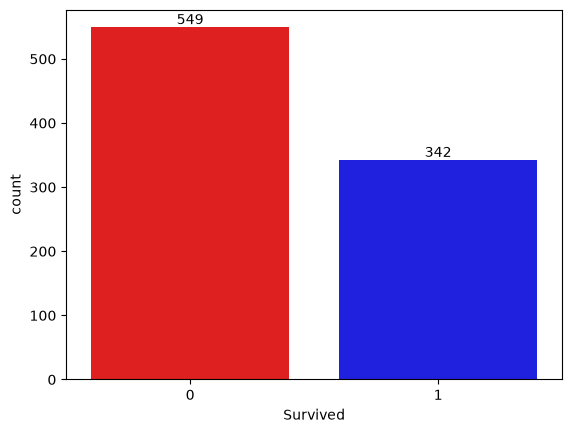

In [12]:
# target distribution
counts = train_df['Survived'].value_counts()
ax = sns.countplot(data=train_df, x= 'Survived', palette= ['red', 'blue'])
for container in ax.containers:
    ax.bar_label(container)
plt.show()

### 2.2. Handling Age Missing Values

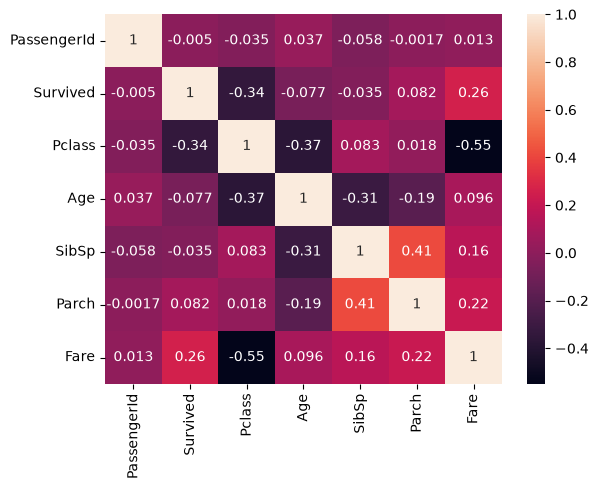

In [13]:
# Heatmap
sns.heatmap(train_df.corr(numeric_only= True), annot= True)
plt.show()

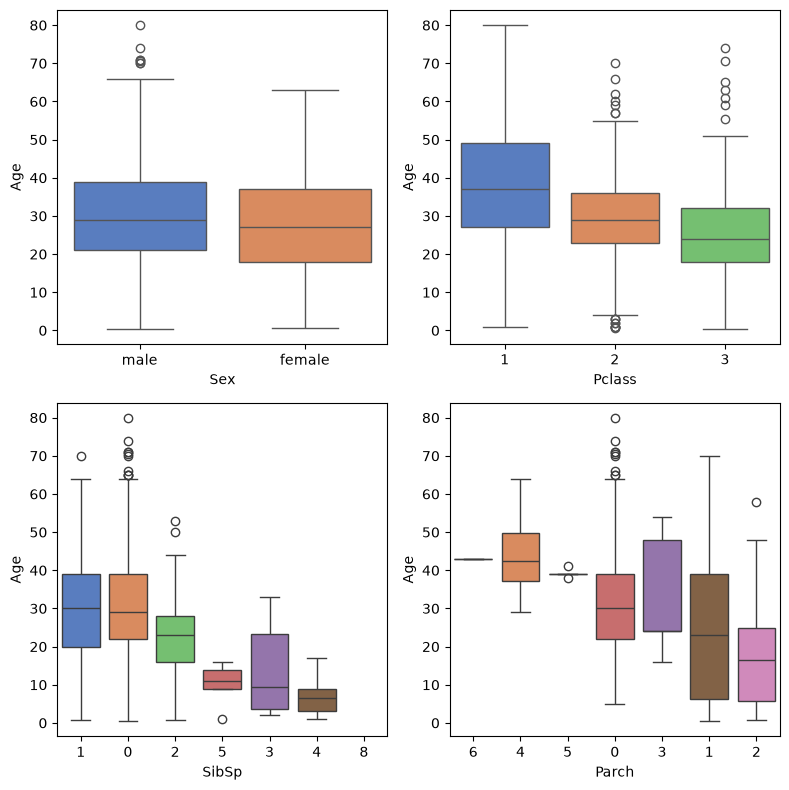

In [14]:
# Let's see what features have more predictive power for age
num_cols = ['Sex' ,'Pclass','SibSp','Parch']
fig, axes = plt.subplots(2,2, figsize=(8,8))

for axe, col in zip(axes.flatten(), num_cols):
    order = train_df.groupby(col)['Age'].median().sort_values(ascending= False).index
    sns.boxplot(data= train_df, x= col, y= 'Age', ax= axe, order= order, palette= 'muted')
plt.tight_layout()
plt.show()

In [15]:
# Checking for Pclass sample size for each group
train_df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [16]:
# Checking for Parch sample size for each group
train_df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [17]:
# Checking for Pclass sample size for each group
train_df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

We see from the boxplots above that the SisSp and Parch have the more predictive power, since they present high variance and consistency within each group. But after checking for the groups sample size, we noticed that there are small sample which cause the data patterns to not be stable.  
So we will fill the Age missing values based on the Pclass, since it presents separation of distributions, consistency within groups, and large sample size of each group. In addition to the sex that can be helpful as well.

In [18]:
# Filling the age missing values
train_df['Age'] = train_df.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))

In [20]:
# A quick check for missing vlues
train_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### 2.3. Handling the Cabin and Embarked Features

Since the Cabin has 687 missing value out of 891 value, it is wise to drop this column since it doesn't have significant predictive power.  
The Cabin has 2 missing values, so it won't hurt if we drop those rows.

In [22]:
# Dropping the Cabin column
train_df = train_df.drop(columns= ['Cabin'])

# Dropping the Embarked NaN rows
train_df = train_df.dropna()

### 2.4. Feature Engineering

In [38]:
# 1. Family Size
train_df['Family_Size'] = train_df['Parch'] + train_df['Pclass'] + 1

# 2. Title
train_df['Title'] = train_df['Name'].str.extract(r",\s*([^\.]+)\.")

In [43]:
test_df.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [39]:
train_df['Title'].value_counts()

Title
Mr              517
Miss            181
Mrs             124
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [40]:
train_df['Title'] = train_df['Title'].replace({'Mlle': 'Miss', 'Mme': 'Mrs', 'Ms': 'Miss'})

rare_titles = [
    'Dr', 'Rev', 'Major', 'Col',
    'Don', 'Lady', 'Sir',
    'Capt', 'the Countess',
    'Jonkheer'
]

train_df['Title'] = train_df['Title'].replace(rare_titles, 'Rare')
